# Tanager atmospheric correction visualization

This notebook inspects the Tanager scene at each stage: L1 top-of-atmosphere reflectance (`Rtoa`), hGRS L2A retrievals (`Rrs`, `brdfg`, and `tcwv`), and Planet's `ortho_sr_hdf5` surface reflectance. It compares L1/L2A RGBs and compares hGRS with Planet in RGB and at matched projected pixels.

The Planet product stores unitless float reflectance directly (no scale or offset); its fill value and bad wavelength bands are masked. hGRS `Rrs` is multiplied by π for RGB and spectrum comparisons.


In [21]:
from pathlib import Path
from datetime import datetime, timezone
import re

import h5py
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from hgrs import Misc, SolarIrradiance, SensorDescription
from hgrs.spectral_sensitivity import Gaussian

ROOT = Path.cwd().parent
TANAGER_L1 = Path('/nethome/lavardma/Documents/data/hyperspectral/tanager/20250606_090504_75_4001_basic_radiance_hdf5.h5')
PLANET_SR = Path('/nethome/lavardma/Documents/data/hyperspectral/tanager/20250606_090504_75_4001_ortho_sr_hdf5.h5')
TANAGER_L2A = ROOT / 'test_data/tanager/20250606_090504_75_4001_L2A.nc'
RGB_WAVELENGTHS_NM = (665.0, 560.0, 490.0)  # red, green, blue
SPECTRUM_PIXEL_ORTHO = (330, 380)            # row, column in the Planet ortho grid
print('L1:', TANAGER_L1, TANAGER_L1.exists())
print('L2A:', TANAGER_L2A, TANAGER_L2A.exists())
print('Planet ortho SR:', PLANET_SR, PLANET_SR.exists())

L1: /nethome/lavardma/Documents/data/hyperspectral/tanager/20250606_090504_75_4001_basic_radiance_hdf5.h5 True
L2A: /home/lavardma/Documents/project/atmospheric/hgrs-refactor/test_data/tanager/20250606_090504_75_4001_L2A.nc True
Planet SR: /nethome/lavardma/Documents/data/hyperspectral/tanager/20250606_090504_75_4001_ortho_sr_hdf5.h5 True


In [22]:
def _rgb_from_xarray(ds, variable, wavelengths=RGB_WAVELENGTHS_NM, factor=1.0):
    """Return RGB array (y, x, 3) sampled at nearest wavelengths."""
    da = ds[variable]
    spectral_dim = 'wl' if 'wl' in da.dims else 'wavelength'
    if spectral_dim not in da.dims:
        raise ValueError(f'{variable} has no wavelength dimension: {da.dims}')
    channels = []
    for wavelength in wavelengths:
        band = da.sel({spectral_dim: wavelength}, method='nearest') * factor
        spatial_dims = [dim for dim in band.dims if dim not in (spectral_dim,)]
        if len(spatial_dims) != 2:
            raise ValueError(f'Expected two spatial dimensions in {variable}: {band.dims}')
        band = band.transpose(*spatial_dims)
        channels.append(np.asarray(band.values, dtype=np.float32))
    return np.stack(channels, axis=-1)


def _stretch_rgb(rgb, limits=None):
    rgb = np.asarray(rgb, dtype=np.float32)
    if limits is None:
        limits = [(np.nanpercentile(rgb[..., c], 2),
                   np.nanpercentile(rgb[..., c], 98)) for c in range(3)]
    output = np.empty_like(rgb)
    for c, (low, high) in enumerate(limits):
        output[..., c] = np.clip((rgb[..., c] - low) / max(high - low, 1e-12), 0, 1)
    return np.power(output, 1 / 1.8), limits


def _plot_rgb_pair(left, right, titles, suptitle):
    """Use shared percentile limits so both panels use the same RGB stretch."""
    both = np.concatenate([left.reshape(-1, 3), right.reshape(-1, 3)], axis=0)
    limits = [(np.nanpercentile(both[:, c], 2), np.nanpercentile(both[:, c], 98))
              for c in range(3)]
    left_view, _ = _stretch_rgb(left, limits)
    right_view, _ = _stretch_rgb(right, limits)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    for ax, image, title in zip(axes, (left_view, right_view), titles):
        ax.imshow(image, origin='upper')
        ax.set_title(title)
        ax.set_axis_off()
    fig.suptitle(suptitle)
    plt.show()


def _show_layer(da, title, cmap='viridis', robust=(2, 98)):
    values = np.asarray(da.values)
    values = np.squeeze(values)
    finite = values[np.isfinite(values)]
    lo, hi = np.percentile(finite, robust) if finite.size else (0, 1)
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    im = ax.imshow(values, origin='upper', cmap=cmap, vmin=lo, vmax=hi)
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.show()


def _select_spatial_band(ds, variable, wavelength=None):
    da = ds[variable]
    if 'wl' in da.dims and wavelength is not None:
        da = da.sel(wl=wavelength, method='nearest')
    return da

## Load the hGRS L2A product and selected L1 `Rtoa` bands

The L2A NetCDF is opened lazily; plotting and spectrum extraction read only selected bands/pixels. The small L1 dataset below is computed from the same Planet `basic_radiance_hdf5` source used by the driver, but reads only the three visible bands needed for the RGB and `Rtoa` panel.

In [23]:
if not TANAGER_L2A.is_file():
    raise FileNotFoundError(f'Edit TANAGER_L2A to point to the corrected product: {TANAGER_L2A}')
l2 = xr.open_dataset(TANAGER_L2A)
print('L2A dimensions:', dict(l2.sizes))
print('L2A variables:', list(l2.data_vars))


def load_l1_rtoa_rgb(path, wavelengths=RGB_WAVELENGTHS_NM):
    fields_path = '/HDFEOS/SWATHS/HYP/Data Fields'
    geo_path = '/HDFEOS/SWATHS/HYP/Geolocation Fields'
    with h5py.File(path, 'r') as src:
        fields, geo = src[fields_path], src[geo_path]
        radiance_ds = fields['toa_radiance']
        all_wl = np.asarray(radiance_ds.attrs['wavelengths'], dtype=np.float64)
        all_fwhm = np.asarray(radiance_ds.attrs['fwhm'], dtype=np.float64)
        order = np.argsort(all_wl)
        all_wl, all_fwhm = all_wl[order], all_fwhm[order]
        indices = np.array([int(np.argmin(np.abs(all_wl - w))) for w in wavelengths])
        radiance = np.stack([radiance_ds[order[i], :, :] for i in indices], axis=-1).astype(np.float32)
        selected_wl, selected_fwhm = all_wl[indices], all_fwhm[indices]
        sza = np.asarray(fields['sun_zenith'][:], dtype=np.float32)
        nodata = np.asarray(fields['nodata_pixels'][:]) != 0
        cloudy = ((np.asarray(fields['beta_cloud_mask'][:]) != 0)
                  | (np.asarray(fields['beta_cirrus_mask'][:]) != 0))
        lon = np.asarray(geo['Longitude'][:], dtype=np.float32)
        lat = np.asarray(geo['Latitude'][:], dtype=np.float32)
        times = np.asarray(geo['Time'][:], dtype=np.float64)
        valid_times = times[times != -9999]
    if not valid_times.size:
        raise ValueError('No valid Tanager acquisition time in L1 source')
    acquisition = datetime.fromtimestamp(float(np.mean(valid_times)), tz=timezone.utc)
    sensor = SensorDescription(name='Tanager RGB', sensor_mod=Gaussian(selected_wl, selected_fwhm))
    f0_full = SolarIrradiance().tsis * Misc.earth_sun_correction(acquisition.timetuple().tm_yday)
    # Convolve the solar spectrum on all source bands, then retain the selected RGB channels.
    full_sensor = SensorDescription(name='Tanager', sensor_mod=Gaussian(all_wl, all_fwhm))
    f0_all = np.asarray(full_sensor.convolve(f0_full, solar_irradiance=True).values)
    f0 = f0_all[indices]
    mu0 = np.cos(np.radians(sza))
    rtoa = np.pi * radiance / (f0[None, None, :] * mu0[..., None])
    invalid = nodata | cloudy | ~np.isfinite(sza) | (sza >= 90)
    rtoa[invalid, :] = np.nan
    rtoa[radiance < 0] = np.nan
    coords = {'y': np.arange(rtoa.shape[0]), 'x': np.arange(rtoa.shape[1]), 'wl': selected_wl}
    return xr.Dataset({'Rtoa': (('y', 'x', 'wl'), rtoa),
                       'lon': (('y', 'x'), lon), 'lat': (('y', 'x'), lat)}, coords=coords)


l1_rgb = load_l1_rtoa_rgb(TANAGER_L1)
print('L1 selected-band dimensions:', dict(l1_rgb.sizes), 'wavelengths:', l1_rgb.wl.values)

L2A dimensions: {'wl': 134, 'y': 617, 'x': 711, 'yc': 31, 'xc': 36}
L2A variables: ['Rrs', 'brdfg_full', 'tcwv', 'tcwv_std', 'water_vapor_validity_mask', 'tcwv_smooth', 'aot_ref', 'brdfg', 'aot_ref_std', 'brdfg_std', 'aerosol_retrieval_validity_mask', 'water_validity_mask', 'aerosol_validity_mask', 'aot_ref_smoothed', 'water_pix_prop', 'pressure', 'to3c', 'tno2c']


/home/lavardma/Documents/project/atmospheric/hgrs-refactor/hgrs/auxdata.py:96: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  solar_irr = xr.open_dataset(thuillier_file).squeeze().data.drop('time') * 1e3


L1 selected-band dimensions: {'y': 501, 'x': 607, 'wl': 3} wavelengths: [665.86999512 560.83001709 490.92999268]


## L1 versus L2A RGB, and L1 `Rtoa`

The RGB panels use a shared percentile stretch. For hGRS L2A, `π × Rrs` is shown to put it in reflectance units comparable to dimensionless `Rtoa`. The `Rtoa` map is the L1 reflectance near 665 nm.

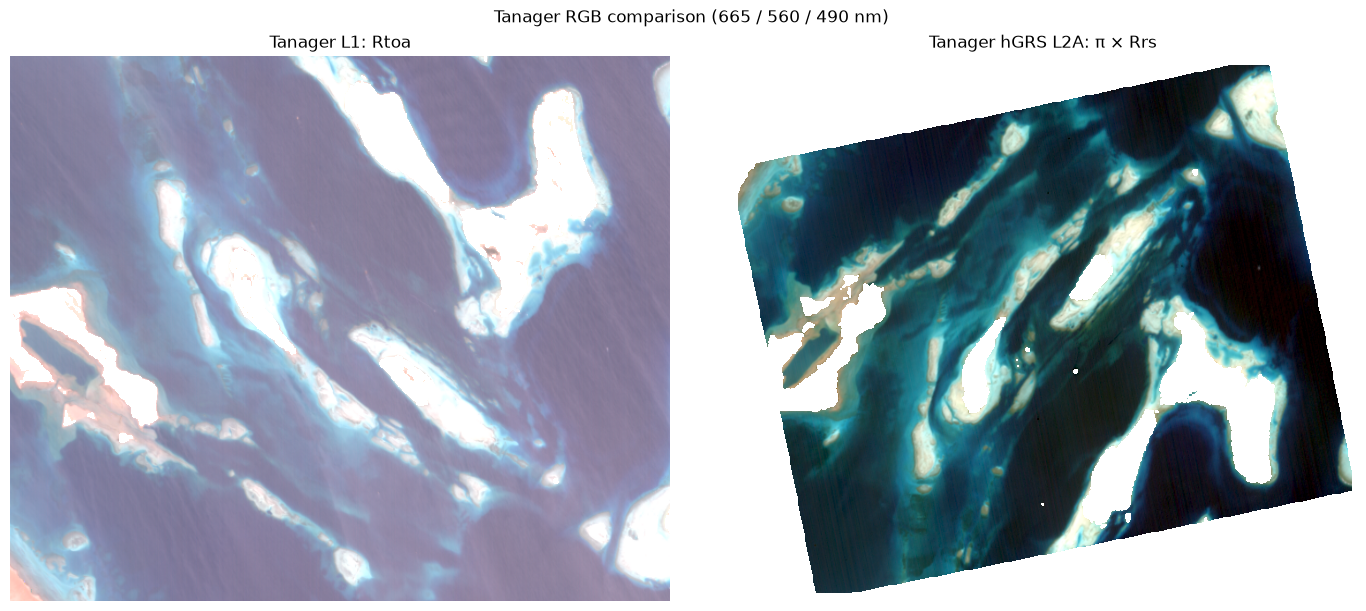

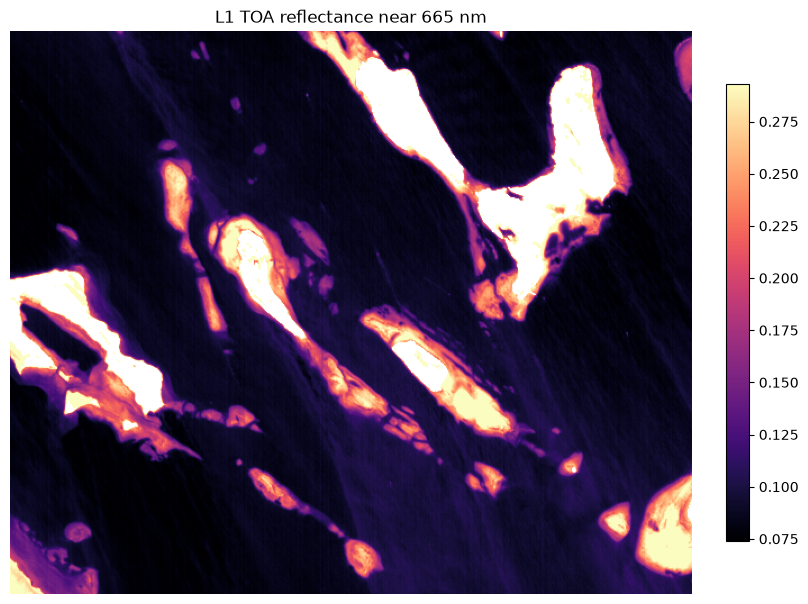

In [24]:
rgb_l1 = _rgb_from_xarray(l1_rgb, 'Rtoa')
rgb_l2 = _rgb_from_xarray(l2, 'Rrs', factor=np.pi)
_plot_rgb_pair(rgb_l1, rgb_l2, ('Tanager L1: Rtoa', 'Tanager hGRS L2A: π × Rrs'),
               'Tanager RGB comparison (665 / 560 / 490 nm)')
_show_layer(_select_spatial_band(l1_rgb, 'Rtoa', 665), 'L1 TOA reflectance near 665 nm', cmap='magma')

## hGRS atmospheric correction fields

`brdfg_full` is displayed when present, with coarse-grid `brdfg` as a fallback. `tcwv` is the retrieved total column water vapour (g/cm²).

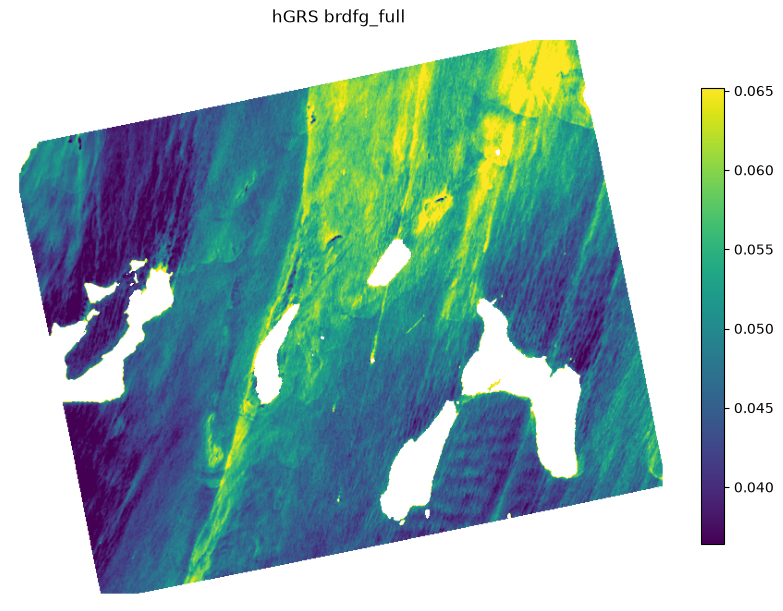

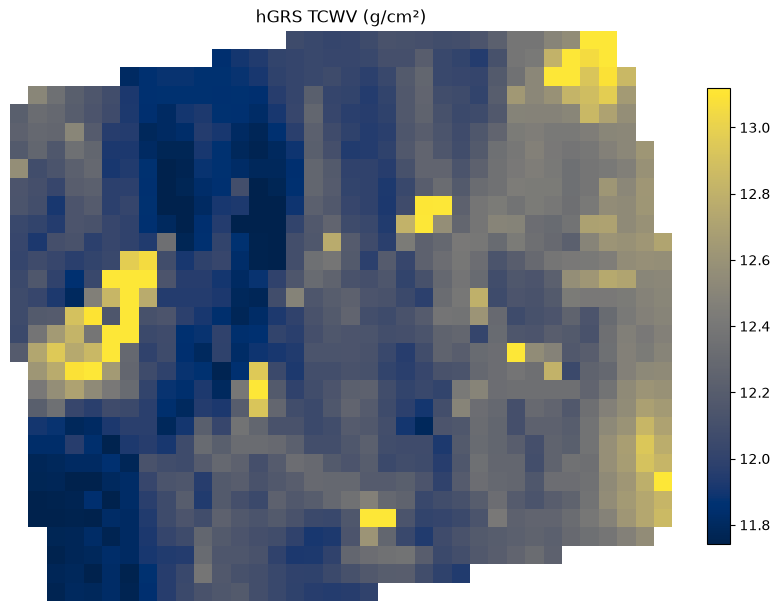

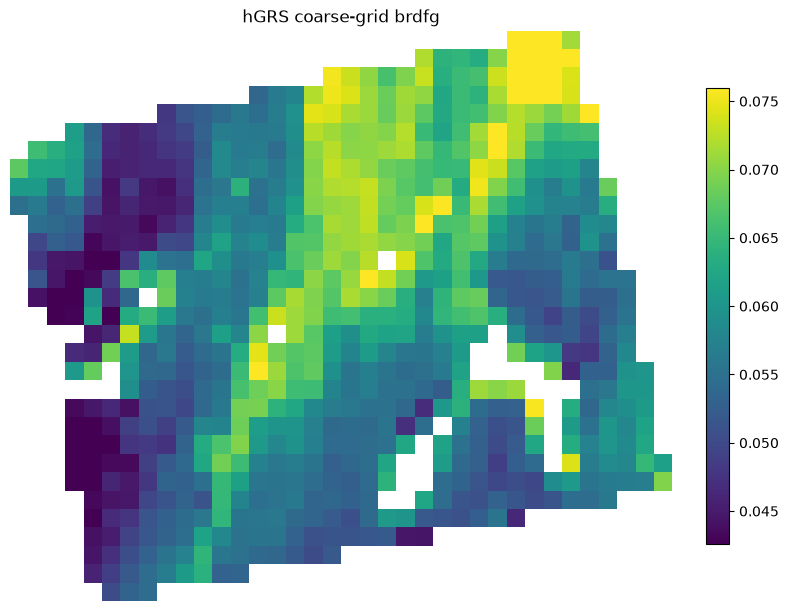

In [25]:
brdfg_name = 'brdfg_full' if 'brdfg_full' in l2 else 'brdfg'
_show_layer(l2[brdfg_name], f'hGRS {brdfg_name}', cmap='viridis')
_show_layer(l2['tcwv'], 'hGRS TCWV (g/cm²)', cmap='cividis')
if 'brdfg' in l2 and brdfg_name != 'brdfg':
    _show_layer(l2['brdfg'], 'hGRS coarse-grid brdfg', cmap='viridis')

## Planet `ortho_sr_hdf5` comparison

Planet provides unitless surface reflectance. hGRS `Rrs` is multiplied by π before comparison. The ortho product is on a projected UTM grid; the decoder reads its HDF-EOS grid bounds and CRS, masks fill values and wavelengths marked invalid, and resamples RGBs onto hGRS coordinates for a spatially aligned view.


In [26]:
def load_planet_ortho_sr(path):
    fields_path = '/HDFEOS/GRIDS/HYP/Data Fields'
    with h5py.File(path, 'r') as src:
        sr = src[f'{fields_path}/surface_reflectance']
        wavelengths = np.asarray(sr.attrs['wavelengths'], dtype=np.float64)
        fill = float(sr.attrs.get('_FillValue', -9999.0))
        unit = sr.attrs.get('Unit', 'Unitless')
        if isinstance(unit, bytes):
            unit = unit.decode('utf-8')
        if str(unit).lower() not in {'unitless', '1', 'reflectance'}:
            raise ValueError(f'Unexpected Planet reflectance unit: {unit!r}')
        good = np.asarray(sr.attrs.get('good_wavelengths', np.ones(wavelengths.size)), dtype=bool)
        if good.size != wavelengths.size:
            raise ValueError('good_wavelengths length does not match spectral dimension')
        # Already float reflectance: no scale_factor/add_offset metadata is present.
        values = np.asarray(sr[:], dtype=np.float32)
        values[values == fill] = np.nan
        values[~good, :, :] = np.nan
        metadata = src['/HDFEOS INFORMATION/StructMetadata.0'][()].decode('ascii', 'replace')
        upper_left = re.search(r'UpperLeftPointMtrs=\(([-+0-9.]+),([-+0-9.]+)\)', metadata)
        lower_right = re.search(r'LowerRightMtrs=\(([-+0-9.]+),([-+0-9.]+)\)', metadata)
        zone = re.search(r'ZoneCode=(\d+)', metadata)
        if not (upper_left and lower_right and zone):
            raise ValueError('Could not decode HDF-EOS projected grid metadata')
        ulx, uly = map(float, upper_left.groups())
        lrx, lry = map(float, lower_right.groups())
        epsg = 32600 + int(zone.group(1))
    ny, nx = values.shape[1:]
    # HDF-EOS PixelRegistration=CORNER: coordinates are pixel centers.
    x = np.linspace(ulx, lrx, nx, endpoint=False) + (lrx-ulx)/(2*nx)
    y = np.linspace(uly, lry, ny, endpoint=False) + (lry-uly)/(2*ny)
    return xr.DataArray(values, dims=('wl', 'y', 'x'),
                        coords={'wl': wavelengths, 'y': y, 'x': x},
                        name='planet_sr', attrs={'crs': f'EPSG:{epsg}', 'units': unit})

planet_sr = load_planet_ortho_sr(PLANET_SR)
# hGRS output coordinates are lon/lat (EPSG:4326); transform them into the
# Planet ortho CRS before sampling the projected SR grid.
from pyproj import Transformer
_to_planet = Transformer.from_crs('EPSG:4326', planet_sr.attrs['crs'], always_xy=True)
lon_grid, lat_grid = np.meshgrid(l2.x.values, l2.y.values)
planet_x_grid, planet_y_grid = _to_planet.transform(lon_grid, lat_grid)
planet_on_hgrs = planet_sr.interp(
    x=xr.DataArray(planet_x_grid, dims=('y', 'x')),
    y=xr.DataArray(planet_y_grid, dims=('y', 'x')), method='nearest')
planet_rgb = _rgb_from_xarray(planet_on_hgrs, 'planet_sr')
hgrs_rgb = _rgb_from_xarray(l2, 'Rrs', factor=np.pi)
_plot_rgb_pair(hgrs_rgb, planet_rgb,
               ('hGRS L2A: π × Rrs', 'Planet ortho surface reflectance (nearest grid match)'),
               'Tanager surface-reflectance RGB comparison (665 / 560 / 490 nm)')
print('Planet selected wavelengths (nm):', [float(planet_sr.wl.values[np.argmin(abs(planet_sr.wl.values-w))]) for w in RGB_WAVELENGTHS_NM])
print('Planet CRS:', planet_sr.attrs['crs'], 'grid:', planet_sr.sizes)


ItemsViewHDF5(<HDF5 file "20250606_090504_75_4001_ortho_sr_hdf5.h5" (mode r)>)


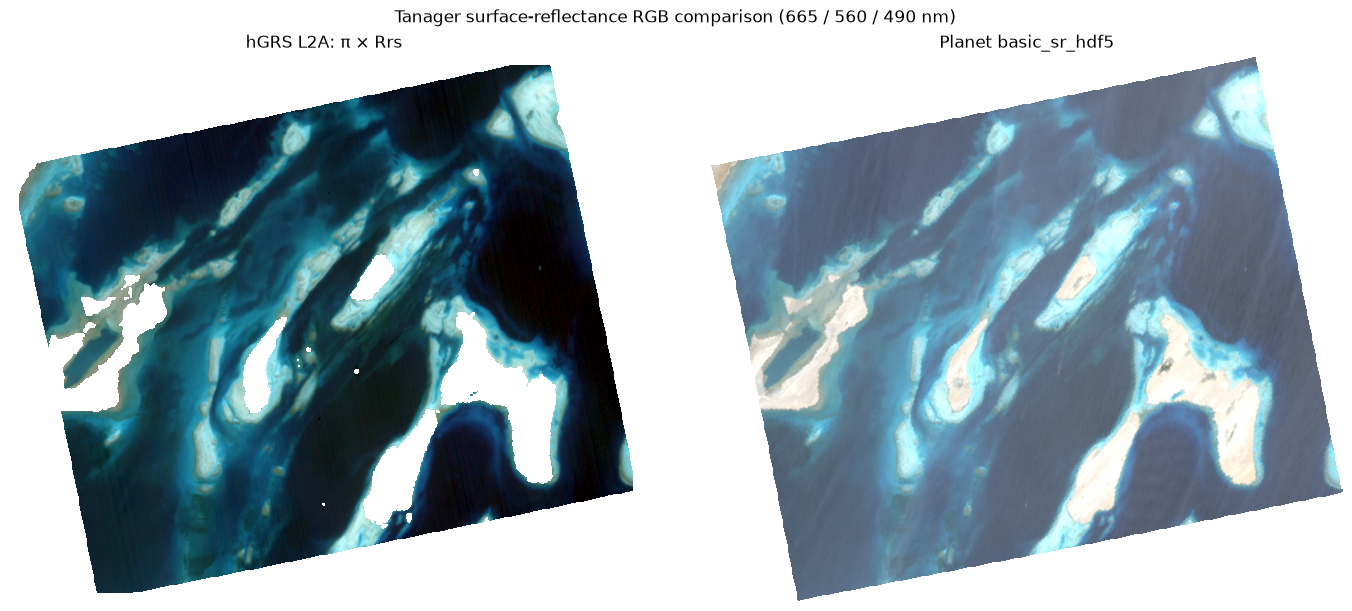

Planet selected wavelengths (nm): [665.86999512 560.83001709 490.92999268]


In [29]:
# SR_FIELDS = '/HDFEOS/SWATHS/HYP/Data Fields'
SR_FIELDS = '/HDFEOS/GRIDS/HYP/Data Fields'

# SR_GEO = '/HDFEOS/SWATHS/HYP/Geolocation Fields'
with h5py.File(PLANET_SR, 'r') as src:
    sr_ds = src[f'{SR_FIELDS}/surface_reflectance']
    sr_wl = np.asarray(sr_ds.attrs['wavelengths'], dtype=np.float64)
    sr_fill = float(sr_ds.attrs.get('_FillValue', -9999.0))
    sr_order = np.argsort(sr_wl)
    sr_wl = sr_wl[sr_order]
    sr_indices = np.array([int(np.argmin(np.abs(sr_wl - w))) for w in RGB_WAVELENGTHS_NM])
    planet_rgb = np.stack([sr_ds[sr_order[i], :, :] for i in sr_indices], axis=-1).astype(np.float32)
    planet_rgb[planet_rgb == sr_fill] = np.nan
    planet_rgb = planet_rgb[::-1]
    # planet_lon = np.asarray(src[f'{SR_GEO}/Longitude'][:], dtype=np.float32)
    # planet_lat = np.asarray(src[f'{SR_GEO}/Latitude'][:], dtype=np.float32)

hgrs_rgb = _rgb_from_xarray(l2, 'Rrs', factor=np.pi)
_plot_rgb_pair(hgrs_rgb, planet_rgb,
               ('hGRS L2A: π × Rrs', 'Planet basic_sr_hdf5'),
               'Tanager surface-reflectance RGB comparison (665 / 560 / 490 nm)')
print('Planet selected wavelengths (nm):', sr_wl[sr_indices])

## Corrected hyperspectral comparison at a matched location

Choose a pixel in the Planet ortho grid. Its projected coordinate is mapped to the nearest hGRS output coordinate, and the spectra are plotted on their native wavelength grids.


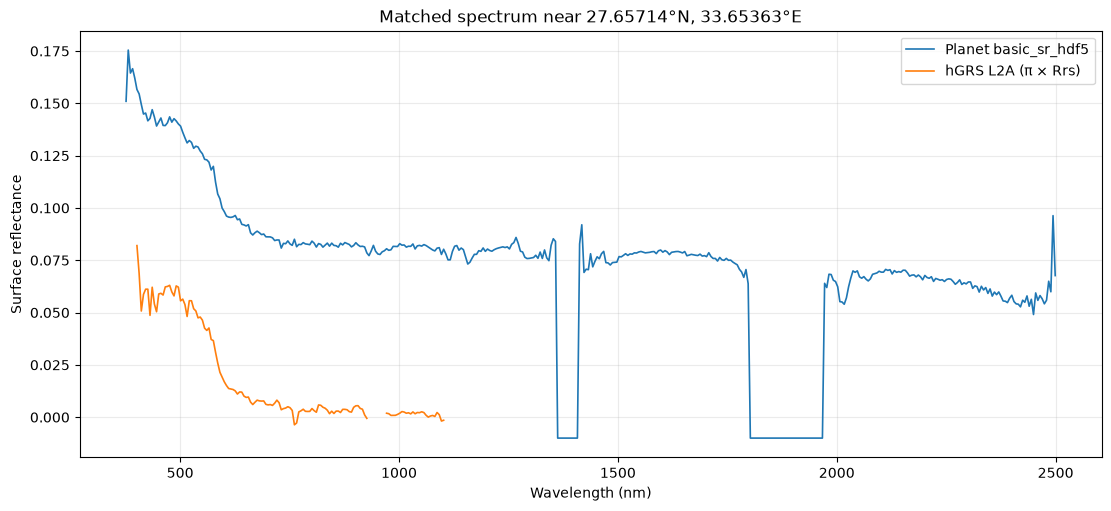

Planet pixel (row=250, col=300); hGRS pixel (y=311, x=353)


In [ ]:
row, col = SPECTRUM_PIXEL_ORTHO
if not (0 <= row < planet_sr.sizes['y'] and 0 <= col < planet_sr.sizes['x']):
    raise IndexError('SPECTRUM_PIXEL_ORTHO is outside the Planet ortho grid')
point_y, point_x = float(planet_sr.y.values[row]), float(planet_sr.x.values[col])
from pyproj import Transformer
_to_lonlat = Transformer.from_crs(planet_sr.attrs['crs'], 'EPSG:4326', always_xy=True)
point_lon, point_lat = _to_lonlat.transform(point_x, point_y)
y_index = int(np.nanargmin(np.abs(np.asarray(l2.y.values) - point_lat)))
x_index = int(np.nanargmin(np.abs(np.asarray(l2.x.values) - point_lon)))
planet_spectrum = np.asarray(planet_sr.isel(y=row, x=col).values, dtype=np.float32)
planet_wavelengths = np.asarray(planet_sr.wl.values, dtype=np.float64)
hgrs_spectrum = (np.asarray(l2['Rrs'].isel(y=y_index, x=x_index).values, dtype=np.float64) * np.pi)

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(planet_wavelengths, planet_spectrum, label='Planet ortho_sr_hdf5', lw=1.2)
ax.plot(l2.wl.values, hgrs_spectrum, label='hGRS L2A (π × Rrs)', lw=1.2)
ax.set(xlabel='Wavelength (nm)', ylabel='Surface reflectance',
       title=f'Matched spectrum near {point_lat:.5f}°N, {point_lon:.5f}°E')
ax.grid(alpha=0.25)
ax.legend()
plt.show()
print(f'Planet ortho pixel (row={row}, col={col}); hGRS pixel (y={y_index}, x={x_index})')


## Corrected hGRS spectrum at a chosen L2A pixel

Set `SPECTRUM_PIXEL_L2A` to a `(y, x)` index in the projected hGRS product to inspect an individual corrected spectrum.

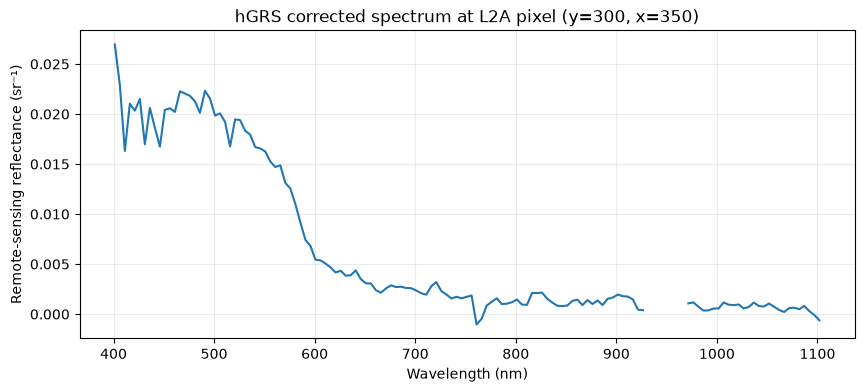

In [ ]:
SPECTRUM_PIXEL_L2A = (300, 350)  # row, column in the hGRS L2A output
sy, sx = SPECTRUM_PIXEL_L2A
spectrum = l2['Rrs'].isel(y=sy, x=sx).values
plt.figure(figsize=(10, 4))
plt.plot(l2.wl.values, spectrum, color='tab:blue')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Remote-sensing reflectance (sr⁻¹)')
plt.title(f'hGRS corrected spectrum at L2A pixel (y={sy}, x={sx})')
plt.grid(alpha=0.25)
plt.show()

Close the lazy NetCDF handle when finished.

In [ ]:
l2.close()